<a href="https://colab.research.google.com/github/nehavelmurugan14-oss/DAA-exp-1-/blob/main/DAA_EXPE_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Input                 DQS Comp       DQS Time       RQS Comp       RQS Time
---------------------------------------------------------------------------
Random                   76921          22.86          71260          15.65
Sorted                12497500        2352.42          71017          12.15
Reverse               12497500        3760.13          66250          11.61
Nearly Sorted           301837          42.27          69727          12.01


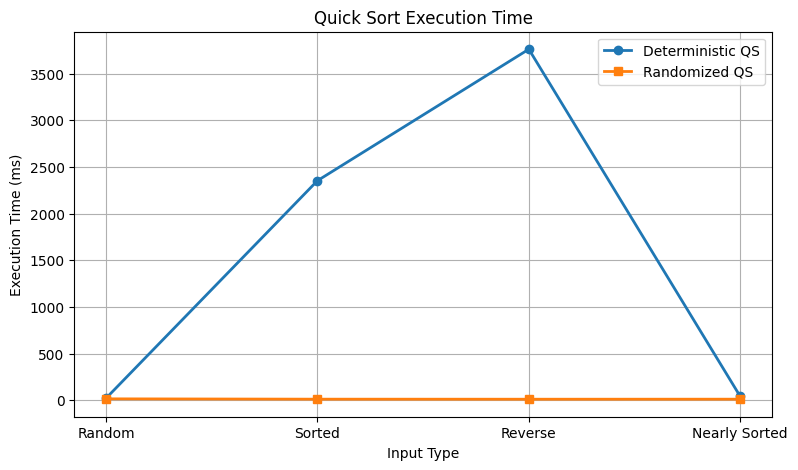

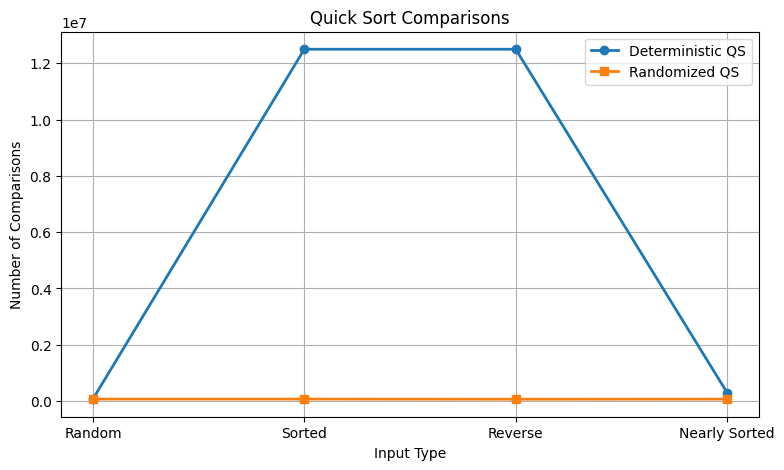

In [1]:
import random
import time
import sys
import matplotlib.pyplot as plt

sys.setrecursionlimit(20000)

comparisons = 0

# ---------------- Partition ----------------
def partition(arr, low, high):
    global comparisons

    pivot = arr[high]
    i = low - 1

    for j in range(low, high):

        comparisons += 1

        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]

    arr[i + 1], arr[high] = arr[high], arr[i + 1]

    return i + 1


# ---------------- Deterministic Quick Sort ----------------
def deterministic_quicksort(arr, low, high):

    if low < high:

        pi = partition(arr, low, high)

        deterministic_quicksort(arr, low, pi - 1)
        deterministic_quicksort(arr, pi + 1, high)


# ---------------- Randomized Quick Sort ----------------
def randomized_quicksort(arr, low, high):

    if low < high:

        random_index = random.randint(low, high)

        arr[random_index], arr[high] = arr[high], arr[random_index]

        pi = partition(arr, low, high)

        randomized_quicksort(arr, low, pi - 1)
        randomized_quicksort(arr, pi + 1, high)


# ---------------- Performance ----------------
def run_test(sort_function, arr):

    global comparisons

    comparisons = 0

    copy = arr[:]

    start = time.perf_counter()

    sort_function(copy, 0, len(copy) - 1)

    elapsed = (time.perf_counter() - start) * 1000

    return comparisons, elapsed


# ---------------- Test Data ----------------
N = 5000

test_cases = {
    "Random": [random.randint(1,100000) for _ in range(N)],
    "Sorted": list(range(N)),
    "Reverse": list(range(N,0,-1)),
    "Nearly Sorted": list(range(N))
}

# Slight shuffle
arr = test_cases["Nearly Sorted"]

for _ in range(N // 20):
    i = random.randint(0,N-1)
    j = random.randint(0,N-1)
    arr[i], arr[j] = arr[j], arr[i]


# ---------------- Comparison ----------------

input_names = []

d_comp = []
r_comp = []

d_time = []
r_time = []

print("{:<15}{:>15}{:>15}{:>15}{:>15}".format(
    "Input",
    "DQS Comp",
    "DQS Time",
    "RQS Comp",
    "RQS Time"))

print("-"*75)

for name, arr in test_cases.items():

    dc, dt = run_test(deterministic_quicksort, arr)

    rc, rt = run_test(randomized_quicksort, arr)

    input_names.append(name)

    d_comp.append(dc)
    r_comp.append(rc)

    d_time.append(dt)
    r_time.append(rt)

    print("{:<15}{:>15}{:>15.2f}{:>15}{:>15.2f}".format(
        name, dc, dt, rc, rt))


# ---------------- Graph 1 ----------------

plt.figure(figsize=(9,5))

plt.plot(input_names,
         d_time,
         marker='o',
         linewidth=2,
         label="Deterministic QS")

plt.plot(input_names,
         r_time,
         marker='s',
         linewidth=2,
         label="Randomized QS")

plt.title("Quick Sort Execution Time")
plt.xlabel("Input Type")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.show()


# ---------------- Graph 2 ----------------

plt.figure(figsize=(9,5))

plt.plot(input_names,
         d_comp,
         marker='o',
         linewidth=2,
         label="Deterministic QS")

plt.plot(input_names,
         r_comp,
         marker='s',
         linewidth=2,
         label="Randomized QS")

plt.title("Quick Sort Comparisons")
plt.xlabel("Input Type")
plt.ylabel("Number of Comparisons")
plt.grid(True)
plt.legend()

plt.show()